# results — read one stored run and plot it

This notebook **computes no dynamics**. It loads `data/run_N{N}.npz`, written by `main.ipynb`, and
draws everything from it. The only thing it reconstructs is the dilated `UnitaryGate` needed to *draw*
a circuit — the run file deliberately does not store the $2^n\times2^n$ unitary.

Set `N` to whichever run you want to look at.

def propagate_memory_single(E, X0, n_steps, m, d):
    """ONE circuit for the non-Markovian case. The memory register is never
    measured and never re-prepared; only the ancilla is read out each step and
    runs with a |1> outcome are discarded. Returns (pops, circuit, info)."""
    D = d * d
    Hm, Qm = arnoldi(E, X0, m)
    m = Hm.shape[0]
    mp = 1 << int(np.ceil(np.log2(m)))
    A = np.zeros((mp, mp), complex)
    A[:m, :m] = Hm
    U, s = dilate(A)
    nq = int(np.log2(mp))

    qr, ar = QuantumRegister(nq, 'mem'), QuantumRegister(1, 'anc')
    cr = ClassicalRegister(n_steps, 'ok')
    qc = QuantumCircuit(qr, ar, cr)
    y = np.zeros(mp, complex)
    y[0] = 1.0
    
    qc.initialize(np.concatenate([y, np.zeros(mp)]), list(qr) + list(ar))
    gate = UnitaryGate(U, label='H_m')

    for t in range(n_steps):
        qc.append(gate, list(qr) + list(ar))
        qc.measure(ar[0], cr[t])        # ONLY the ancilla
        qc.reset(ar[0])

    # the |0...0> branch the post-selection keeps, with the classical norm bookkeeping
    scale = np.linalg.norm(X0)
    yv = y.copy()
    p_tot = 1.0
    pops = [np.real(np.diag((Qm @ yv[:m] * scale)[:D].reshape(d, d, order='F')))]

    for _ in range(n_steps):
        top = (U @ np.concatenate([yv, np.zeros(mp)]))[:mp]
        nrm = np.linalg.norm(top)
        p_tot *= nrm ** 2
        yv = top / nrm
        scale = scale * nrm * s
        pops.append(np.real(np.diag((Qm @ yv[:m] * scale)[:D].reshape(d, d, order='F'))))

    return np.array(pops), qc, dict(m=m, n_qubits=nq + 1, s=s, p_success=p_tot, norm_Hm=float(np.linalg.norm(Hm, 2)))

In [1]:
import os
os.makedirs('pictures', exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import import_ipynb
from validation_and_helpers import load_run, channel_of

N = 7                                        # which stored run to plot (4 or 7)
run = load_run(f'data/run_N{N}.npz')

d, dt_fs, t_fs = run['d'], run['dt_fs'], run['t_fs']
res, bench_rho, ref = run['res'], run['bench_rho'], run['ref']
sweep, pops_K1 = run['sweep'], run['pops_K1']
bench = {n: np.real(np.einsum('tii->ti', r)) for n, r in bench_rho.items()}

methods = ('Path integral', 'HEOM', 'Lindblad')
to_plot = list(methods)                      # comment a name out to hide that curve
col = {'Path integral': '#d62728', 'HEOM': '#1f77b4', 'Lindblad': '#2ca02c'}
bench_label = {'Path integral': 'qutip HEOM (exact ref.)',
               'HEOM': 'qutip HEOMSolver',
               'Lindblad': 'qutip mesolve'}

print(f"N = {N}  (D = {d*d}),  K_heom = {run['K_heom']},  K_pi = {run['K_pi']},  "
      f"HEOM depth = {run['heom_depth']} ({run['n_ado']} ADOs),  TEMPO chi_max = {run['chi_max']}")
print('\nmethod          qubits  circuits  ancilla |0>  vs qutip   vs classical ref')
print('---------------------------------------------------------------------------')
for n in methods:
    r = res[n]
    print(f"{n:15s} {r['n_qubits']:4d} {r['n_circuits']:9d}      {r['p_success']:.3f}   "
          f"{np.abs(r['pops'] - bench[n]).max():.2e}      "
          f"{np.abs(r['pops'] - ref[n]).max():.1e}")

N = 7  (D = 49),  K_heom = 15,  K_pi = 10,  HEOM depth = 2 (120 ADOs),  TEMPO chi_max = 64

method          qubits  circuits  ancilla |0>  vs qutip   vs classical ref
---------------------------------------------------------------------------
Path integral     10        91      0.466   4.18e-02      4.8e-15
HEOM              11        86      0.476   2.33e-03      9.1e-15
Lindblad           7      4900      0.004   1.73e-08      1.3e-15


## The circuit that is re-executed at every step

The whole point of the enhanced algorithm is that this one object never changes while the trajectory is
produced. Rebuilding it from the stored $E$ costs one `sqrtm`.

In [2]:
from qiskit import QuantumCircuit, transpile

chans = {n: channel_of(res[n]) for n in methods}      # rebuilt from E / kraus_dt

print(f"{'method':16s}{'qubits':>7}{'register':>10}{'padded':>8}{'s=||A||':>9}"
      f"{'anc |0>':>9}{'|U*U-I|':>10}{'circuits':>10}")
print('-' * 79)
for n in methods:
    r, ch = res[n], chans[n]
    print(f"{n:16s}{ch.n_qubits:7d}{ch.dim:10d}{ch.pad:8d}{ch.s:9.4f}"
          f"{r['p_success']:9.3f}{r['unitarity']:10.1e}{r['n_circuits']:10d}")

print('\ncost of compiling the reused gate down to hardware gates (u, cx):')
for n in methods:
    ch = chans[n]
    if ch.n_qubits <= 6:
        bare = QuantumCircuit(ch.n_qubits)          # the gate alone: the state-loading
        bare.append(ch.gate, range(ch.n_qubits))    # Aer instructions have no gate basis
        tq = transpile(bare, basis_gates=['u', 'cx'], optimization_level=1)
        print(f"  {n:15s} depth {tq.depth():6d}   cx {tq.count_ops().get('cx', 0):6d}"
              f"   total {sum(tq.count_ops().values()):6d}")
    else:
        print(f"  {n:15s} skipped — synthesising an arbitrary {ch.n_qubits}-qubit unitary "
              f"costs O(4^{ch.n_qubits}) ~ {4 ** ch.n_qubits:.0e} CX")

method           qubits  register  padded  s=||A||  anc |0>   |U*U-I|  circuits
-------------------------------------------------------------------------------
Path integral        10       490     512   1.4142    0.466   1.0e-11        91
HEOM                 11       735    1024   1.4142    0.476   4.2e-12        86
Lindblad              7        49      64   0.0001    0.004   1.4e-10      4900

cost of compiling the reused gate down to hardware gates (u, cx):
  Path integral   skipped — synthesising an arbitrary 10-qubit unitary costs O(4^10) ~ 1e+06 CX
  HEOM            skipped — synthesising an arbitrary 11-qubit unitary costs O(4^11) ~ 4e+06 CX
  Lindblad        skipped — synthesising an arbitrary 7-qubit unitary costs O(4^7) ~ 2e+04 CX


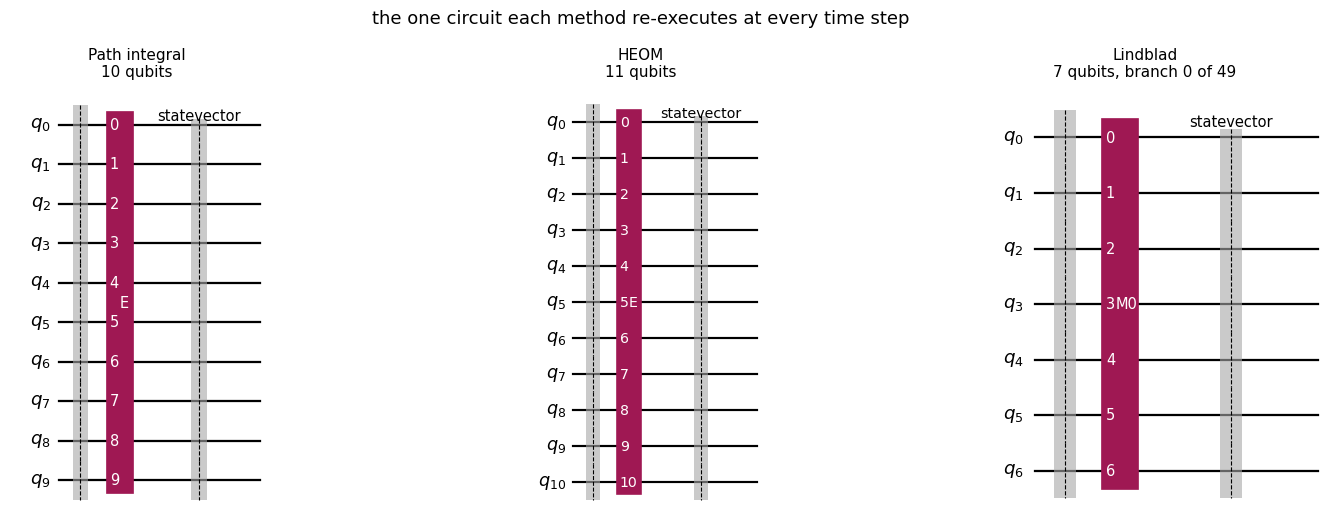

wrote pictures/circuits_N7.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
for ax, n in zip(axes, methods):
    ch = chans[n]
    qc = ch.circuit(np.ones(ch.dim))            # exactly the circuit run each step
    qc.draw(output='mpl', ax=ax)
    tag = '' if 'E' in res[n] else f", branch 0 of {res[n]['n_kraus']}"
    ax.set_title(f"{n}\n{ch.n_qubits} qubits{tag}", fontsize=11, pad=12)
fig.suptitle('the one circuit each method re-executes at every time step', fontsize=13)
fig.tight_layout()
fig.savefig(f'pictures/circuits_N{N}.png', dpi=200)
plt.show()
print(f'wrote pictures/circuits_N{N}.png')

## Populations from the quantum circuits vs the ordinary qutip solvers

One panel per site, one colour per method: **solid** = Qiskit grid, **dashed black** = qutip. The
dotted vertical line in each method's own colour marks the end of its memory window $K\Delta t$ — the
only stretch that method ever had computed classically. Everything to the right of a line comes out of
that method's repeated circuit.

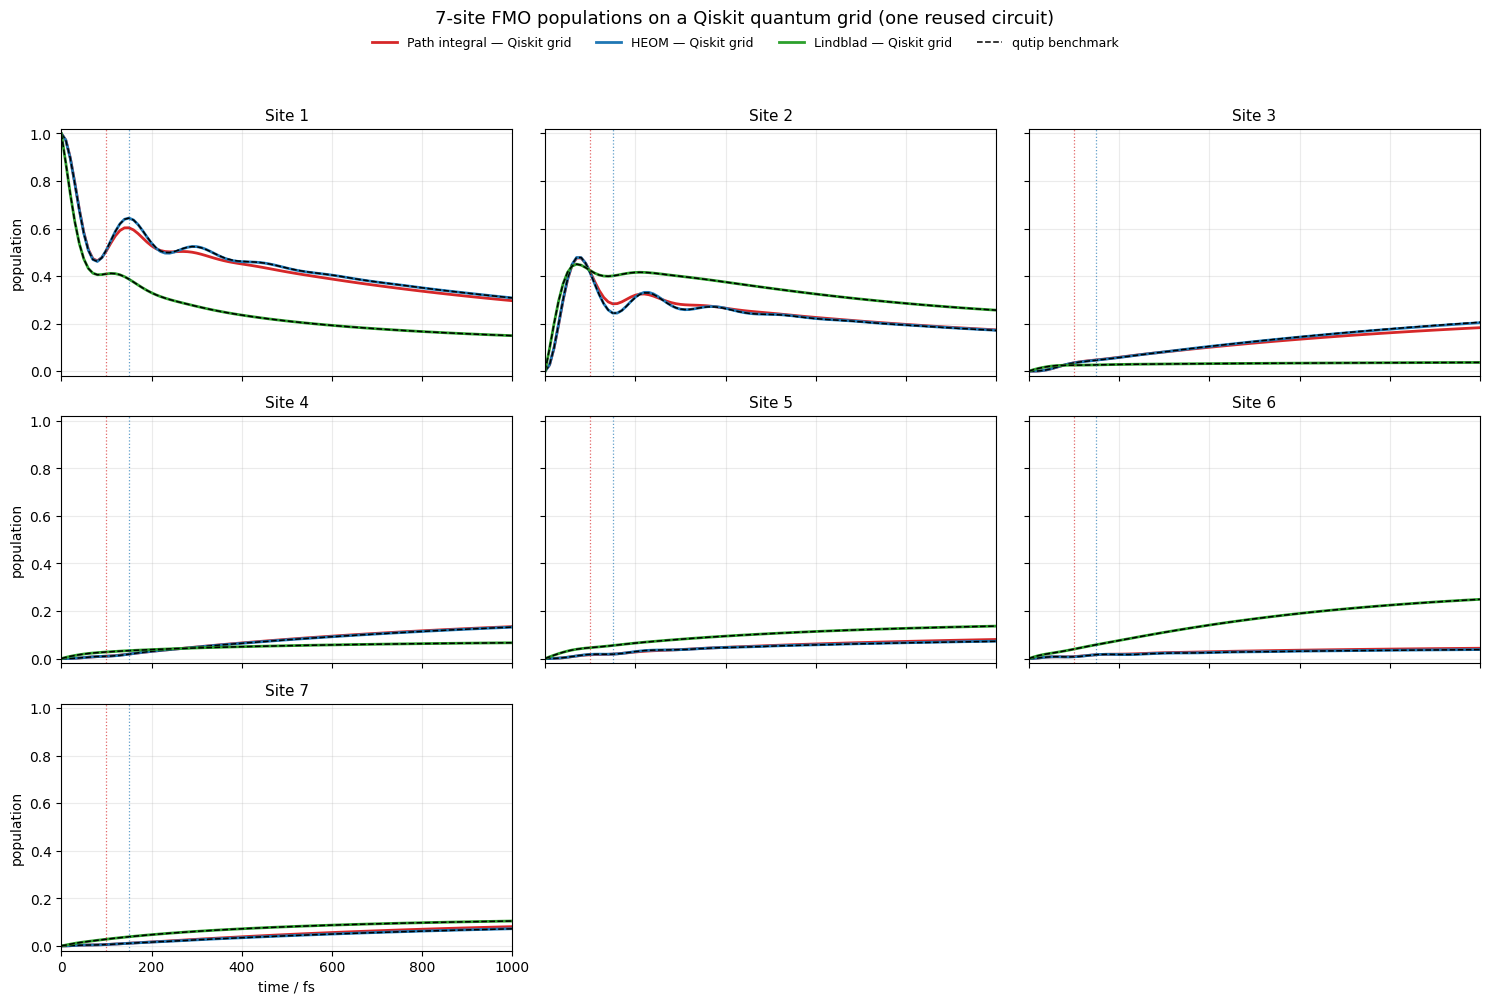

wrote pictures/qiskit_vs_qutip_N7.png


In [4]:
ncol = 2 if d <= 4 else 3
nrow = int(np.ceil(d / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.4 * nrow),
                         sharex=True, sharey=True, squeeze=False)
for site, ax in enumerate(axes.flat):
    if site >= d:
        ax.axis('off')
        continue
    for n in to_plot:
        ax.plot(t_fs, res[n]['pops'][:, site], color=col[n], ls='-', lw=2.0)
        ax.plot(t_fs, bench[n][:, site], color='k', ls='--', lw=1.1)
    for nm in ('Path integral', 'HEOM'):        # each method's own learning window
        if nm in to_plot:
            ax.axvline(res[nm]['K'] * dt_fs, color=col[nm], lw=0.9, ls=':', alpha=0.7)
    ax.set_title(f'Site {site + 1}', fontsize=11)
    ax.set_xlim(0, 1000); ax.set_ylim(-0.02, 1.02); ax.grid(alpha=0.25)
    if site // ncol == nrow - 1: ax.set_xlabel('time / fs')
    if site % ncol == 0: ax.set_ylabel('population')

handles = [Line2D([], [], color=col[n], lw=2.0, label=f'{n} — Qiskit grid') for n in to_plot]
handles.append(Line2D([], [], color='k', ls='--', lw=1.1, label='qutip benchmark'))
fig.legend(handles=handles, loc='upper center', ncol=4, frameon=False, fontsize=9,
           bbox_to_anchor=(0.5, 0.965))
fig.suptitle(f'{d}-site FMO populations on a Qiskit quantum grid (one reused circuit)', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(f'pictures/qiskit_vs_qutip_N{N}.png', dpi=200); plt.show()
print(f'wrote pictures/qiskit_vs_qutip_N{N}.png')

### The off-diagonal elements

The populations are only the diagonal of $\rho$; the transport is carried by the **coherences**
$\rho_{ij}$, $i<j$. They are the harder test: populations are constrained by $\sum_i\rho_{ii}=1$,
while the coherences oscillate, change sign and decay, so an error in the dilation or in the memory
register shows up here first.

For $N=4$ there are 6 of them and all 12 real curves fit a $3\times4$ matrix. For $N=7$ there are 21,
so only the largest few are shown — the full list of deviations is printed underneath.

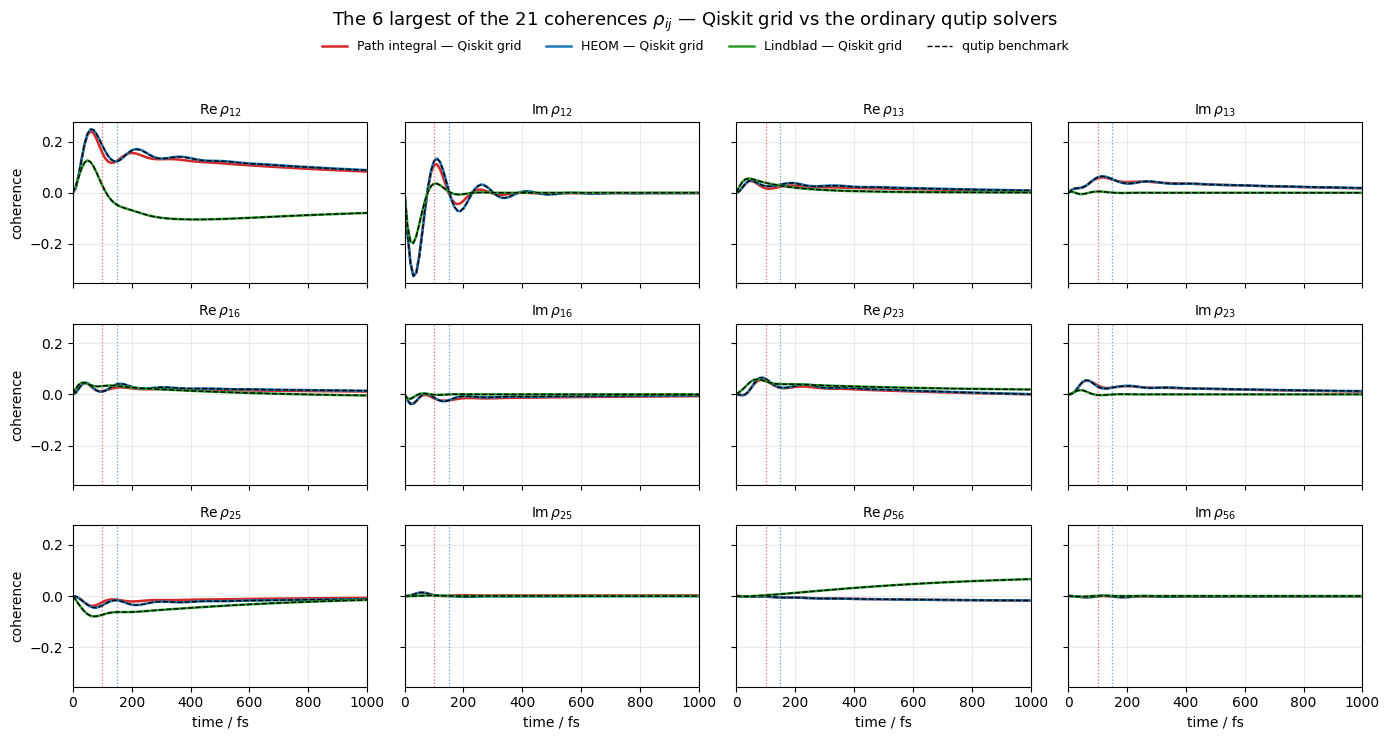

wrote pictures/qiskit_vs_qutip_coherences_N7.png

largest coherence deviation from qutip, over all 21 pairs:
  Path integral   3.60e-02
  HEOM            2.04e-03
  Lindblad        3.33e-08


In [5]:
pairs = [(i, j) for i in range(d) for j in range(i + 1, d)]

# N=4 -> all 6 pairs (12 panels, 3x4). Larger N -> the 6 strongest, same layout.
if len(pairs) > 6:
    strength = {p: max(np.abs(res[n]['rho'][:, p[0], p[1]]).max() for n in to_plot)
                for p in pairs}
    shown = sorted(sorted(pairs, key=strength.get, reverse=True)[:6])
else:
    shown = pairs
parts = [(p, f) for p in shown for f in ('Re', 'Im')]

fig, axes = plt.subplots(3, 4, figsize=(14, 7.5), sharex=True, sharey=True)
for ax, ((i, j), part) in zip(axes.flat, parts):
    take = np.real if part == 'Re' else np.imag
    for n in to_plot:
        ax.plot(t_fs, take(res[n]['rho'][:, i, j]), color=col[n], ls='-', lw=1.8)
        ax.plot(t_fs, take(bench_rho[n][:, i, j]), color='k', ls='--', lw=1.0)
    for nm in ('Path integral', 'HEOM'):
        if nm in to_plot:
            ax.axvline(res[nm]['K'] * dt_fs, color=col[nm], lw=0.9, ls=':', alpha=0.7)
    ax.set_title(rf'{part}$\,\rho_{{{i+1}{j+1}}}$', fontsize=10)
    ax.set_xlim(0, 1000); ax.grid(alpha=0.25)
for ax in axes[-1]:
    ax.set_xlabel('time / fs')
for ax in axes[:, 0]:
    ax.set_ylabel('coherence')

handles = [Line2D([], [], color=col[n], lw=1.8, label=f'{n} — Qiskit grid') for n in to_plot]
handles.append(Line2D([], [], color='k', ls='--', lw=1.0, label='qutip benchmark'))
fig.legend(handles=handles, loc='upper center', ncol=4, frameon=False, fontsize=9,
           bbox_to_anchor=(0.5, 0.955))
title = ('Coherences $\\rho_{ij}$' if len(pairs) == len(shown)
         else f'The 6 largest of the {len(pairs)} coherences $\\rho_{{ij}}$')
fig.suptitle(f'{title} — Qiskit grid vs the ordinary qutip solvers', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(f'pictures/qiskit_vs_qutip_coherences_N{N}.png', dpi=200); plt.show()
print(f'wrote pictures/qiskit_vs_qutip_coherences_N{N}.png')

print('\nlargest coherence deviation from qutip, over all '
      f'{len(pairs)} pairs:')
for n in to_plot:
    worst = max(np.abs(res[n]['rho'][:, i, j] - bench_rho[n][:, i, j]).max() for i, j in pairs)
    print(f'  {n:15s} {worst:.2e}')

## Deviation of the quantum-grid result from the qutip benchmark

**Lindblad** is exact (GKSL is divisible), so its deviation is pure solver tolerance. **HEOM** and the
**path integral** are non-Markovian and reconstructed from a finite memory window — they follow the
benchmark to machine precision through the learning window and then settle at their own floors. The
grey curve is the same path-integral circuit with the memory thrown away ($K=1$), which is what makes
the register necessary.

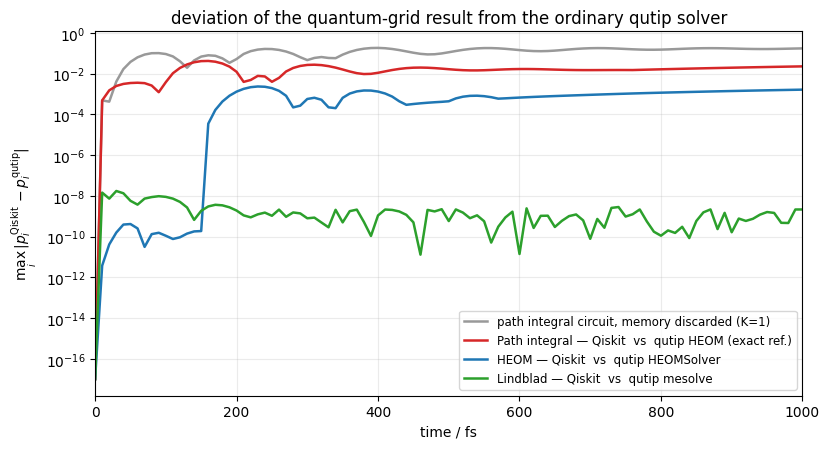

wrote pictures/qiskit_deviation_N7.png


In [6]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.semilogy(t_fs, np.maximum(np.abs(pops_K1 - bench['Path integral']).max(axis=1), 1e-17),
            color='#999999', lw=1.8, label='path integral circuit, memory discarded (K=1)')
for n in methods:
    ax.semilogy(t_fs, np.maximum(np.abs(res[n]['pops'] - bench[n]).max(axis=1), 1e-17),
                color=col[n], lw=1.8, label=f'{n} — Qiskit  vs  {bench_label[n]}')
ax.set_xlabel('time / fs'); ax.set_ylabel(r'$\max_i\,|p_i^{\rm Qiskit} - p_i^{\rm qutip}|$')
ax.set_title('deviation of the quantum-grid result from the ordinary qutip solver')
ax.set_xlim(0, 1000); ax.grid(alpha=0.25, which='both'); ax.legend(fontsize=8.5, loc='lower right')
fig.tight_layout(); fig.savefig(f'pictures/qiskit_deviation_N{N}.png', dpi=200); plt.show()
print(f'wrote pictures/qiskit_deviation_N{N}.png')

## What the memory window costs in qubits

The window length $K$ is set by how fast the transfer tensors $\|T_m\|$ decay, and it fixes the size of
the register the circuit has to carry ($K\cdot D$ amplitudes padded to a power of two, plus the
dilation ancilla).

Path integral
   K   K*dt/fs    vs qutip
  ----------------------------
   1       10    1.82e-01
   5       50    9.62e-02
  10      100    4.18e-02

HEOM
   K   K*dt/fs    vs qutip
  ----------------------------
   1       10    1.77e-01
   5       50    7.51e-02
  10      100    5.62e-03
  15      150    2.33e-03
  20      200    7.75e-04
  25      250    1.90e-04



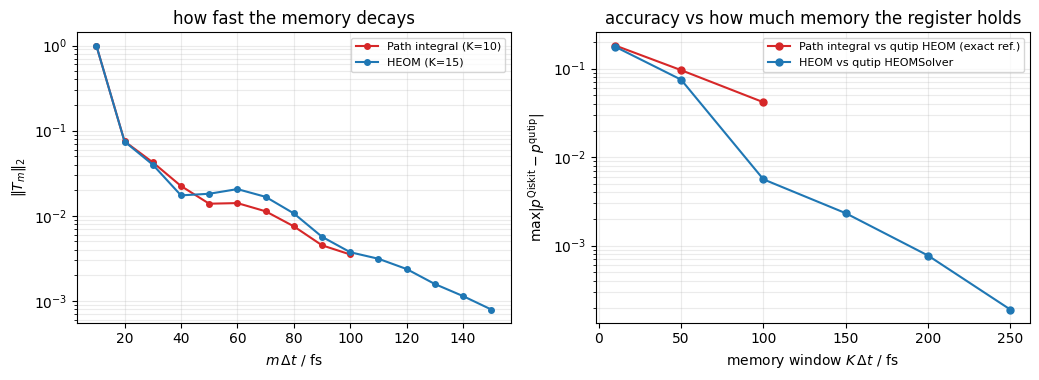

wrote pictures/memory_window_N7.png


In [7]:
for n, (ks, devs) in sweep.items():
    print(f'{n}')
    print('   K   K*dt/fs    vs qutip')
    print('  ' + '-' * 28)
    for k, dv in zip(ks, devs):
        print(f'  {k:2d}   {k*dt_fs:6.0f}    {dv:.2e}')
    print()

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.9))
for n in sweep:
    Tn = res[n]['T_norms']                      # length = that method's own window
    axes[0].semilogy(np.arange(1, len(Tn) + 1) * dt_fs, Tn, 'o-', ms=4,
                     color=col[n], label=f"{n} (K={res[n]['K']})")
axes[0].set_xlabel(r'$m\,\Delta t$ / fs'); axes[0].set_ylabel(r'$\|T_m\|_2$')
axes[0].set_title('how fast the memory decays')
axes[0].grid(alpha=0.25, which='both'); axes[0].legend(fontsize=8)

for n, (ks, devs) in sweep.items():
    axes[1].semilogy(np.array(ks) * dt_fs, devs, 'o-', ms=5,
                     color=col[n], label=f'{n} vs {bench_label[n]}')
axes[1].set_xlabel(r'memory window $K\,\Delta t$ / fs')
axes[1].set_ylabel(r'$\max|p^{\rm Qiskit}-p^{\rm qutip}|$')
axes[1].set_title('accuracy vs how much memory the register holds')
axes[1].grid(alpha=0.25, which='both'); axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(f'pictures/memory_window_N{N}.png', dpi=200); plt.show()
print(f'wrote pictures/memory_window_N{N}.png')

## Is the reused operator actually a *valid* propagator?

**Left — stability.** Iterating one fixed operator $E$ a hundred times is only safe if its spectrum lies
inside the unit disk; an eigenvalue with $|\lambda|>1$ would blow the trajectory up. Both methods sit
*on* the circle and never outside it — the eigenvalue $1$ is the trace-preserving fixed point every
physical map must have, i.e. marginal stability, which is correct.

**Right — physicality.** The circuit renormalises after every ancilla post-selection, so trace
preservation is not automatic. Where the drift is large it is inherited from the input maps (the TEMPO
maps are themselves only trace-preserving to the MPS truncation), not produced by the circuit.

spectral radius of the reused operator (must be <= 1 for a stable iteration)
  Path integral   max|lambda(E)| = 0.999962
  HEOM            max|lambda(E)| = 1.000000

trace preservation of the circuit output
  Path integral   max|Tr rho - 1| = 7.0e-03
  HEOM            max|Tr rho - 1| = 5.2e-13
  Lindblad        max|Tr rho - 1| = 8.0e-14


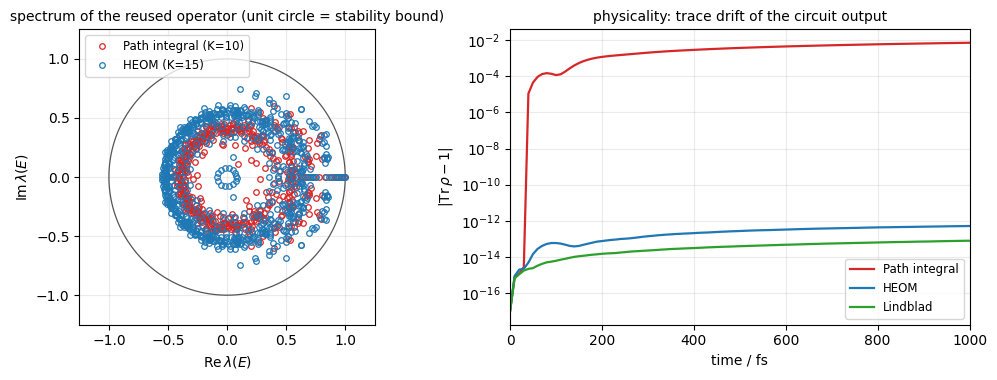

wrote pictures/validity_N7.png


In [8]:
print('spectral radius of the reused operator (must be <= 1 for a stable iteration)')
for n in ('Path integral', 'HEOM'):
    print(f"  {n:15s} max|lambda(E)| = {np.abs(np.linalg.eigvals(res[n]['E'])).max():.6f}")
print('\ntrace preservation of the circuit output')
for n in methods:
    tr = np.abs(np.trace(res[n]['rho'], axis1=1, axis2=2) - 1.0)
    print(f"  {n:15s} max|Tr rho - 1| = {tr.max():.1e}")

fig, (a0, a1) = plt.subplots(1, 2, figsize=(10.5, 3.9))
th = np.linspace(0, 2 * np.pi, 200)
a0.plot(np.cos(th), np.sin(th), color='#555555', lw=0.9)
for n in ('Path integral', 'HEOM'):
    ev = np.linalg.eigvals(res[n]['E'])
    a0.plot(ev.real, ev.imag, 'o', ms=4, mfc='none', mew=0.9, color=col[n],
            label=f"{n} (K={res[n]['K']})")
a0.set_aspect('equal'); a0.set_xlim(-1.25, 1.25); a0.set_ylim(-1.25, 1.25)
a0.set_xlabel(r'$\mathrm{Re}\,\lambda(E)$'); a0.set_ylabel(r'$\mathrm{Im}\,\lambda(E)$')
a0.set_title('spectrum of the reused operator (unit circle = stability bound)', fontsize=10)
a0.grid(alpha=0.25); a0.legend(fontsize=8.5, loc='upper left')

for n in methods:
    tr = np.abs(np.trace(res[n]['rho'], axis1=1, axis2=2) - 1.0)
    a1.semilogy(t_fs, np.maximum(tr, 1e-17), color=col[n], lw=1.6, label=n)
a1.set_xlim(0, 1000)
a1.set_xlabel('time / fs'); a1.set_ylabel(r'$|\mathrm{Tr}\,\rho - 1|$')
a1.set_title('physicality: trace drift of the circuit output', fontsize=10)
a1.grid(alpha=0.25, which='both'); a1.legend(fontsize=8.5)
fig.tight_layout()
fig.savefig(f'pictures/validity_N{N}.png', dpi=200); plt.show()
print(f'wrote pictures/validity_N{N}.png')